In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/customer_features.csv")

df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,promo_dependency_level,value_score,value_tier,loyalty_def_1,loyalty_def_2,customer_segment,age_group,spend_level,retention_score,retention_level
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,High Promo Dependency,0.403006,Mid Value,0,0,One-Time Bargain Hunters,55+,Medium Spend,0.480128,Medium Retention
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,High Promo Dependency,0.381378,Mid Value,0,0,One-Time Bargain Hunters,18-24,Medium Spend,0.335359,Low Retention
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,High Promo Dependency,0.547269,Premium Value,0,0,One-Time Bargain Hunters,45-54,Medium Spend,0.643026,High Retention
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,High Promo Dependency,0.739019,Premium Value,1,0,Promo-Dependent Regulars,18-24,High Spend,0.956179,High Retention
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,High Promo Dependency,0.358051,Mid Value,0,0,One-Time Bargain Hunters,45-54,Medium Spend,0.454718,Medium Retention


In [2]:
features = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases",
    "frequency_score",
    "promo_dependency_score",
    "satisfaction_flag",
    "subscription_flag",
    "value_score",
    "retention_score"
]

X = df[features]

X.head()

,age,purchase_amount,review_rating,previous_purchases,frequency_score,promo_dependency_score,satisfaction_flag,subscription_flag,value_score,retention_score
0,55,53,3.1,14,6,1.0,0,1,0.403006,0.480128
1,19,64,3.1,2,6,1.0,0,1,0.381378,0.335359
2,50,73,3.1,23,7,1.0,0,1,0.547269,0.643026
3,21,90,3.5,49,7,1.0,0,1,0.739019,0.956179
4,45,49,2.7,31,2,1.0,0,1,0.358051,0.454718


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

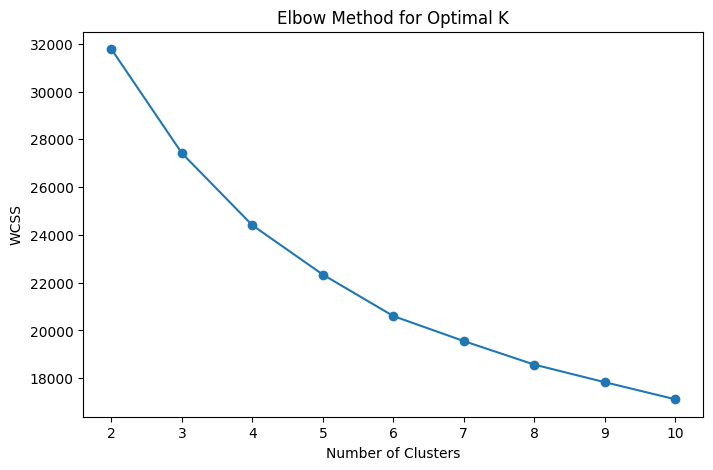

In [4]:
wcss = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [5]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score:.3f}")

k=2, silhouette score=0.168
k=3, silhouette score=0.167
k=4, silhouette score=0.173
k=5, silhouette score=0.179
k=6, silhouette score=0.191
k=7, silhouette score=0.188
k=8, silhouette score=0.181
k=9, silhouette score=0.180
k=10, silhouette score=0.173


In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df["ml_cluster"] = kmeans.fit_predict(X_scaled)

df["ml_cluster"].value_counts()

ml_cluster
4    863
0    813
3    799
1    792
2    633
Name: count, dtype: int64

In [7]:
cluster_summary = df.groupby("ml_cluster").agg({
    "age": "mean",
    "purchase_amount": "mean",
    "review_rating": "mean",
    "previous_purchases": "mean",
    "frequency_score": "mean",
    "promo_dependency_score": "mean",
    "subscription_flag": "mean",
    "value_score": "mean",
    "retention_score": "mean"
}).round(2)

cluster_summary

,age,purchase_amount,review_rating,previous_purchases,frequency_score,promo_dependency_score,subscription_flag,value_score,retention_score
ml_cluster,,,,,,,,,
0,43.19,55.37,4.47,15.19,3.43,0.36,0.19,0.39,0.34
1,44.96,63.49,3.23,36.32,4.83,0.22,0.00,0.45,0.67
2,43.78,57.81,3.26,25.95,4.18,1.00,1.00,0.43,0.51
3,43.88,66.63,4.47,35.98,4.85,0.47,0.33,0.58,0.67
4,44.46,55.57,3.24,14.57,3.40,0.23,0.01,0.27,0.33


In [8]:
cluster_name_map = {
    0: "Stable Mid-Value Customers",
    1: "Champions",
    2: "Promo-Dependent Regulars",
    3: "One-Time Bargain Hunters",
    4: "At-Risk Low Value Customers"
}

df["ml_customer_segment"] = df["ml_cluster"].map(cluster_name_map)

In [9]:
df[["ml_cluster", "ml_customer_segment"]].head()

,ml_cluster,ml_customer_segment
0,2,Promo-Dependent Regulars
1,2,Promo-Dependent Regulars
2,2,Promo-Dependent Regulars
3,3,One-Time Bargain Hunters
4,2,Promo-Dependent Regulars


In [10]:
pd.crosstab(df["customer_segment"], df["ml_customer_segment"])

ml_customer_segment,At-Risk Low Value Customers,Champions,One-Time Bargain Hunters,Promo-Dependent Regulars,Stable Mid-Value Customers
customer_segment,,,,,
At-Risk Low Value Customers,652,320,0,0,0
Champions,0,0,164,0,0
One-Time Bargain Hunters,193,68,202,478,294
Promo-Dependent Regulars,7,106,172,155,2
Stable Mid-Value Customers,11,298,261,0,517


In [11]:
df.to_csv("../data/processed/final_customer_segments.csv", index=False)